In [2]:
import matplotlib.pyplot as plt
from PIL import Image
import os

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
from torchtext.vocab import Vocab
from torchtext.vocab import build_vocab_from_iterator
from torchsummary import summary

from collections import Counter
from sklearn.metrics import accuracy_score, precision_score

ModuleNotFoundError: No module named 'torch'

In [1]:
import torchtext


ModuleNotFoundError: No module named 'torchtext'

In [ ]:
print("PyTorch version:", torch.__version__)
print("torchtext version:", torchtext.__version__)
print("Python version:", os.sys.version)

# Descrição do projeto


# 1. Carregar o dataset


In [3]:
train_images_path = './Images/train'
train_labels_path = './Text/train'
test_images_path = './Images/test'
test_labels_path = './Text/test'

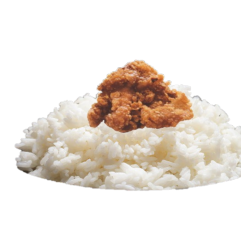

Set the fried chicken atop a bed of fragrant rice.
Lay the fried chicken portions on the rice.
Position the fried chicken onto the rice.
Arrange the fried chicken over the rice.
Place a bed of rice on a plate or in a bowl, and then arrange the fried chicken over it.
Put the fried chicken over the rice.
Craft a satisfying dish by placing a serving of rice on a plate or in a bowl and then adding the crispy fried chicken on top as a savory finishing touch.
To assemble the dish, start with a serving of rice and then add the fried chicken on top of it.
Place fried chicken on rice.


In [6]:
# Carregar a primeira imagem
image_file = f'{train_images_path}/1.png' 
image = Image.open(image_file)

# Carregar o primeiro texto
text_file = f'{train_labels_path}/1.txt'
with open(text_file, 'r') as file:
    text = file.read()

# Plotar a imagem e o texto
plt.figure(figsize=(3, 3))

# Mostrar a imagem
plt.imshow(image)
plt.axis('off')

plt.show()
print(text)

### 1. Dataset

In [8]:
class Bento800Dataset(Dataset):
    def __init__(self, images_dir, texts_dir, transform=None, vocab=None, max_length=50):
        self.images_dir = images_dir
        self.texts_dir = texts_dir
        self.transform = transform
        self.max_length = max_length

        if vocab is None:
            raise ValueError("Vocabulário (vocab) não pode ser None. Certifique-se de passar um dicionário de vocabulário.")

        self.vocab = vocab
        self.image_filenames = [f for f in os.listdir(images_dir) if f.endswith('.png')]

        print(f"Número de imagens encontradas: {len(self.image_filenames)}")

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        # Carrega a imagem
        img_name = self.image_filenames[idx]
        img_path = os.path.join(self.images_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        # Carrega o texto correspondente
        text_name = os.path.splitext(img_name)[0] + '.txt'
        text_path = os.path.join(self.texts_dir, text_name)

        with open(text_path, 'r') as file:
            text = file.read().strip()

        # Convertendo o texto para tokens (índices)
        tokens = self.text_to_indices(text)

        # Preenchendo os tokens até o comprimento máximo
        if len(tokens) > self.max_length:
            tokens = tokens[:self.max_length]
        else:
            tokens = tokens + [self.vocab['<PAD>']] * (self.max_length - len(tokens))

        tokens = torch.tensor(tokens, dtype=torch.long)

        return image, tokens

    def text_to_indices(self, text):
        # Supondo que vocabulário seja um dicionário {'palavra': índice}
        return [self.vocab.get(word, self.vocab['<UNK>']) for word in text.split()]

NameError: name 'Dataset' is not defined

### 1.2 Funções auxiliares

In [9]:

def build_vocab(texts_dir, min_freq=1):
    """
    Constrói um vocabulário a partir dos textos em texts_dir.

    Args:
        texts_dir (str): Caminho para o diretório com os textos.
        min_freq (int): Frequência mínima para incluir uma palavra no vocabulário.

    Returns:
        vocab (dict): Dicionário que mapeia palavras para índices.
    """
    counter = Counter()

    # Iterar sobre todos os arquivos de texto
    for text_file in os.listdir(texts_dir):
        text_path = os.path.join(texts_dir, text_file)

        with open(text_path, 'r') as file:
            text = file.read().strip()
            words = text.split()
            counter.update(words)

    # Construir vocabulário com palavras que têm frequência maior ou igual a min_freq
    vocab = {'<PAD>': 0, '<UNK>': 1, '<start>': 2, '<end>': 3}
    idx = 4

    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = idx
            idx += 1

    return vocab

In [10]:
# Construindo o vocabulário
vocab = build_vocab(train_labels_path, min_freq=1)
vocab_size = len(vocab)
print(f"Vocab size: {vocab_size}")
print(f"Sample vocab: {list(vocab.items())[:10]}")

Vocab size: 254
Sample vocab: [('<PAD>', 0), ('<UNK>', 1), ('<start>', 2), ('<end>', 3), ('Set', 4), ('the', 5), ('fried', 6), ('chicken', 7), ('atop', 8), ('a', 9)]


In [11]:
# Definindo transformações para as imagens (redimensionamento, normalização, etc.)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

NameError: name 'transforms' is not defined

In [12]:
def custom_collate_fn(batch):
    images, captions = zip(*batch)

    # Empilhando as imagens. Todas devem ter o mesmo tamanho
    images = torch.stack(images, 0)

    # Preenchendo as sequências para o mesmo comprimento
    caption_lengths = [len(caption) for caption in captions]
    max_length = max(caption_lengths)
    padded_captions = torch.zeros(len(captions), max_length).long()

    for i, caption in enumerate(captions):
        end = caption_lengths[i]
        padded_captions[i, :end] = caption[:end]

    return images, padded_captions

### 1.3 Criando os datasets

In [15]:
# Criando os datasets
train_dataset = Bento800Dataset(
    images_dir=train_images_path,
    texts_dir=train_labels_path,
    transform=transform,
    vocab=vocab
)

test_dataset = Bento800Dataset(
    images_dir=test_images_path,
    texts_dir=test_labels_path,
    transform=transform,
    vocab=vocab
)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, collate_fn=custom_collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, collate_fn=custom_collate_fn)
train_loader_iter = iter(train_loader)
images, texts = next(train_loader_iter)

NameError: name 'Bento800Dataset' is not defined

In [14]:
# Função para mostrar a imagem e o texto correspondente
def show_sample(image, text):
    plt.imshow(image.permute(1, 2, 0))  # Converte a imagem de [C, H, W] para [H, W, C]
    plt.axis('off')
    plt.show()
    print(text)

# Obtendo uma amostra do dataset de treino
train_loader_iter = iter(train_loader)
images, texts = next(train_loader_iter)

# Exibindo as primeiras 3 amostras
for i in range(3):
    show_sample(images[i], texts[i])

NameError: name 'train_loader' is not defined

# 2. Modelo

### 2.1 Attention Model


In [ ]:
class Attention(nn.Module):
    def __init__(self, feature_dim, hidden_dim, attention_dim):
        super(Attention, self).__init__()
        self.attention_fc = nn.Linear(feature_dim + hidden_dim, attention_dim)
        self.attention_out = nn.Linear(attention_dim, 1)

    def forward(self, features, hidden_state):

        hidden_state = hidden_state.unsqueeze(1).repeat(1, features.size(1), 1)
        attention_input = torch.cat([features, hidden_state], dim=2)
        attention_score = torch.tanh(self.attention_fc(attention_input))
        attention_weights = torch.softmax(self.attention_out(attention_score), dim=1)
        context_vector = torch.sum(attention_weights * features, dim=1)

        return context_vector, attention_weights

### 2.2 Encoder

In [16]:
class CNNEncoder(nn.Module):
    def __init__(self):
        super(CNNEncoder, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, 256)
        self.dropout = nn.Dropout(0.5)  # Dropout de 50%

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)  # Flatten na saída
        x = self.dropout(F.relu(self.fc1(x)))  # Adicionar Dropout
        features = self.dropout(F.relu(self.fc2(x)))  # Adicionar Dropout
        return features

NameError: name 'nn' is not defined

### 2.3 Decoder

In [17]:
class RNNDecoderWithAttention(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers, feature_dim, attention_dim):
        super(RNNDecoderWithAttention, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.attention = Attention(feature_dim, hidden_dim, attention_dim)
        self.lstm = nn.LSTM(input_size=embedding_dim + feature_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True, dropout=0.5)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, features, captions):
        embedded = self.embedding(captions)
        hidden_state = torch.zeros(features.size(0), self.lstm.hidden_size).to(features.device)
        context_vector, _ = self.attention(features, hidden_state)

        lstm_input = torch.cat((context_vector.unsqueeze(1).repeat(1, embedded.size(1), 1), embedded), dim=2)
        lstm_out, _ = self.lstm(lstm_input)
        outputs = self.fc(lstm_out)
        return outputs

NameError: name 'nn' is not defined

### 2.4 Attention-based LSTM

In [18]:
class ImageToTextModelWithAttention(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers, feature_dim, attention_dim):
        super(ImageToTextModelWithAttention, self).__init__()
        self.encoder = CNNEncoder()
        self.decoder = RNNDecoderWithAttention(vocab_size, embedding_dim, hidden_dim, num_layers, feature_dim, attention_dim)

    def forward(self, images, captions):
        features = self.encoder(images).unsqueeze(1)
        outputs = self.decoder(features, captions)
        return outputs

NameError: name 'nn' is not defined

In [19]:
# Assumindo o dispositivo está definido como 'cpu' ou 'cuda'
model = ImageToTextModelWithAttention(vocab_size=5000, embedding_dim=256, hidden_dim=512, num_layers=2, feature_dim=256, attention_dim=256).to(device)

# Sumário para o Encoder CNN
print("Sumário CNN Encoder:")
summary(model.encoder, input_size=(3, 224, 224))

def get_decoder_summary(model, features, captions):
    model.eval()  # Definir o modelo em modo de avaliação
    with torch.no_grad():
        output = model(features, captions)
    return output

# Exemplo de entradas
features_example = torch.randn(2, 49, 256)  # batch_size=2, num_pixels=49, feature_dim=256
captions_example = torch.randint(0, 5000, (2, 50))  # batch_size=2, seq_len=50

# Obter o resumo do decodificador
outputs = get_decoder_summary(model.decoder, features_example, captions_example)

# Imprimir a arquitetura do modelo
print("RNNDecoderWithAttention Architecture:")
print(model.decoder)
print("\nExample Output Shape:", outputs.shape)

ModuleNotFoundError: No module named 'torchsummary'